# Phase 7.1: Prompt Diagnostics

Before diving into the core trajectory analysis, we diagnose the hidden state extraction to ensure there are no issues with the prompt design and the representation. We focus on the final token representation at the last layer.

## Diagnostic A: Category Counts

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import torch
from glob import glob

from src.dimensionality_reduction import load_all_trajectories
from src.load_prompts import load_prompts

print("Loading prompts...")
prompts = load_prompts("../data/prompts/prompts.jsonl")
prompt_dict = {str(p["id"]): p for p in prompts}

print("Loading trajectories...")
trajectories = load_all_trajectories("gpt2", "../data/trajectories")

category_counts = {}
for t in trajectories:
    pid = str(t.prompt_id)
    if pid in prompt_dict:
        cat = prompt_dict[pid].get("group", "unknown")
        category_counts[cat] = category_counts.get(cat, 0) + 1
        
print("\n--- Category Counts ---")
for cat, count in category_counts.items():
    print(f"{cat}: {count}")

C:\Users\bisha\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\cuda\__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loading prompts...
Loading trajectories...

--- Category Counts ---
analogies: 10
animals: 10
emotions: 10
reasoning: 10
vehicles: 10


## Diagnostic B: PCA 2D Separation

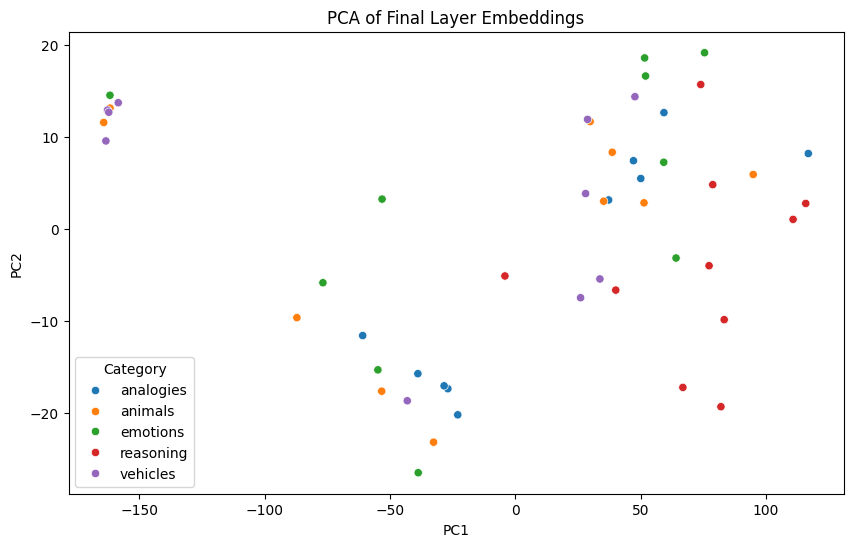

In [2]:
final_embeddings = []
labels = []

for t in trajectories:
    pid = str(t.prompt_id)
    if pid in prompt_dict:
        cat = prompt_dict[pid].get("group", "unknown")
        # Final layer is the last element in trajectory [L, D]
        final_embeddings.append(t.trajectory[-1].numpy())
        labels.append(cat)
        
final_embeddings = np.array(final_embeddings)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(final_embeddings)

df = pd.DataFrame({
    "PC1": pca_result[:, 0],
    "PC2": pca_result[:, 1],
    "Category": labels
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="PC1", y="PC2", hue="Category", palette="tab10")
plt.title("PCA of Final Layer Embeddings")
plt.show()

## Diagnostic C: Raw-Space Silhouette Score

In [3]:
if len(set(labels)) > 1:
    sil_score = silhouette_score(final_embeddings, labels)
    print(f"Silhouette Score (Raw 768-D space): {sil_score:.4f}")
else:
    print("Not enough categories to compute silhouette score.")

Silhouette Score (Raw 768-D space): -0.1131
